<a href="https://colab.research.google.com/github/DVBharath2005/COVID-19-Data-Analysis-Visualization/blob/main/COVID_19_Data_Analysis_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-02-24          5.0        5.0   
1      AFG      Asia  Afghanistan  2020-02-25          5.0        0.0   
2      AFG      Asia  Afghanistan  2020-02-26          5.0        0.0   
3      AFG      Asia  Afghanistan  2020-02-27          5.0        0.0   
4      AFG      Asia  Afghanistan  2020-02-28          5.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         NaN                  NaN  ...   
1                 NaN           NaN         NaN                  NaN  ...   
2                 NaN           NaN         NaN                  NaN  ...   
3                 NaN           NaN         NaN                  NaN  ...   
4                 NaN           NaN         NaN                  NaN  ...   

   female_smokers  male_smokers  handwashing_facilities  \
0             NaN        

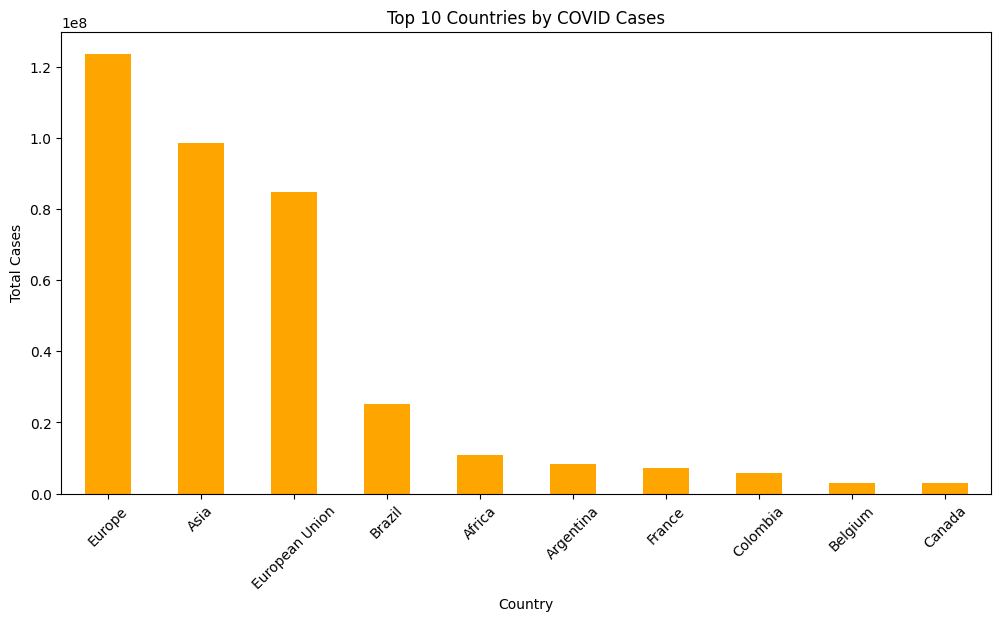

Skipping COVID-19 Correlation Heatmap as india_df is empty or lacks sufficient data.
Skipping COVID-19 Cases vs Deaths pie chart as india_df is empty.
Skipping Interactive COVID-19 Cases in India plot as india_df is empty.


Skipping Mortality Rate Analysis as india_df is empty.
Skipping saving cleaned data as india_df is empty.


In [ ]:
# =========================================================
# COVID-19 Data Analysis & Visualization Project
# =========================================================

# Install Required Libraries:
# pip install pandas numpy matplotlib seaborn plotly

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# =========================================================
# LOAD DATASET
# =========================================================

# Download dataset from:
# https://ourworldindata.org/covid-deaths

df = pd.read_csv("/content/covid_data.csv")

# =========================================================
# DISPLAY BASIC INFORMATION
# =========================================================

print("First 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# =========================================================
# DATA CLEANING
# =========================================================

# Convert date column into datetime
df['date'] = pd.to_datetime(df['date'])

# Fill missing values with 0
df.fillna(0, inplace=True)

# =========================================================
# FILTER INDIA DATA
# =========================================================

india_df = df[df['location'].str.strip().str.lower() == 'india']

# =========================================================
# TOTAL CASES, DEATHS, RECOVERIES
# =========================================================

# Check if india_df is empty before proceeding
if not india_df.empty:
    latest_data = india_df.iloc[-1]

    print("\n========== INDIA COVID SUMMARY ==========")
    print("Total Cases:", int(latest_data['total_cases']))
    print("Total Deaths:", int(latest_data['total_deaths']))
    print("Total Vaccinations:", int(latest_data['total_vaccinations']))
else:
    print("\nNo data available for India after filtering.")

# =========================================================
# TOP 10 COUNTRIES BY TOTAL CASES
# =========================================================

top_countries = (
    df.groupby('location')['total_cases']
    .max()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Countries by Total Cases:")
print(top_countries)

# =========================================================
# VISUALIZATION 1:
# DAILY NEW CASES IN INDIA
# =========================================================

# Only attempt to plot if india_df is not empty
if not india_df.empty:
    plt.figure(figsize=(14, 6))

    plt.plot(
        india_df['date'],
        india_df['new_cases'],
        color='blue'
    )

    plt.title("Daily COVID-19 Cases in India")
    plt.xlabel("Date")
    plt.ylabel("New Cases")
    plt.grid(True)

    plt.show()
else:
    print("Skipping Daily COVID-19 Cases in India plot as india_df is empty.")

# =========================================================
# VISUALIZATION 2:
# DAILY DEATHS IN INDIA
# =========================================================

# Only attempt to plot if india_df is not empty
if not india_df.empty:
    plt.figure(figsize=(14, 6))

    plt.plot(
        india_df['date'],
        india_df['new_deaths'],
        color='red'
    )

    plt.title("Daily COVID-19 Deaths in India")
    plt.xlabel("Date")
    plt.ylabel("Deaths")
    plt.grid(True)

    plt.show()
else:
    print("Skipping Daily COVID-19 Deaths in India plot as india_df is empty.")

# =========================================================
# VISUALIZATION 3:
# TOP 10 COUNTRIES BAR CHART
# =========================================================

plt.figure(figsize=(12, 6))

top_countries.plot(
    kind='bar',
    color='orange'
)

plt.title("Top 10 Countries by COVID Cases")
plt.xlabel("Country")
plt.ylabel("Total Cases")

plt.xticks(rotation=45)

plt.show()

# =========================================================
# VISUALIZATION 4:
# HEATMAP
# =========================================================

# Only attempt to plot if india_df is not empty and has enough data
if not india_df.empty and len(india_df.columns) > 1:
    heatmap_data = india_df[
        [
            'total_cases',
            'new_cases',
            'total_deaths',
            'new_deaths',
            'total_vaccinations'
        ]
    ]

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        heatmap_data.corr(),
        annot=True,
        cmap='coolwarm'
    )

    plt.title("COVID-19 Correlation Heatmap")

    plt.show()
else:
    print("Skipping COVID-19 Correlation Heatmap as india_df is empty or lacks sufficient data.")

# =========================================================
# VISUALIZATION 5:
# PIE CHART
# =========================================================

# Only attempt to plot if india_df is not empty
if not india_df.empty:
    labels = ['Cases', 'Deaths']

    sizes = [
        latest_data['total_cases'],
        latest_data['total_deaths']
    ]

    colors = ['skyblue', 'red']

    plt.figure(figsize=(7, 7))

    plt.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%'
    )

    plt.title("COVID-19 Cases vs Deaths")

    plt.show()
else:
    print("Skipping COVID-19 Cases vs Deaths pie chart as india_df is empty.")

# =========================================================
# INTERACTIVE PLOTLY GRAPH
# =========================================================

# Only attempt to plot if india_df is not empty
if not india_df.empty:
    fig = px.line(
        india_df,
        x='date',
        y='new_cases',
        title='Interactive COVID-19 Cases in India'
    )

    fig.show()
else:
    print("Skipping Interactive COVID-19 Cases in India plot as india_df is empty.")

# =========================================================
# WORLD MAP VISUALIZATION
# =========================================================

latest_global = df[df['date'] == df['date'].max()]

fig = px.choropleth(
    latest_global,
    locations="iso_code",
    color="total_cases",
    hover_name="location",
    color_continuous_scale="Reds",
    title="Worldwide COVID-19 Cases"
)

fig.show()

# =========================================================
# MORTALITY RATE ANALYSIS
# =========================================================

# Only attempt calculation if india_df is not empty
if not india_df.empty:
    india_df['mortality_rate'] = (
        india_df['total_deaths'] / india_df['total_cases']
    ) * 100

    print("\nMortality Rate:")
    print(india_df[['date', 'mortality_rate']].tail())
else:
    print("Skipping Mortality Rate Analysis as india_df is empty.")

# =========================================================
# SAVE CLEANED DATA
# =========================================================

# Only attempt to save if india_df is not empty
if not india_df.empty:
    india_df.to_csv("cleaned_india_covid_data.csv", index=False)

    print("\nCleaned dataset saved successfully!")
else:
    print("Skipping saving cleaned data as india_df is empty.")

# =========================================================
# END OF PROJECT
# =========================================================